# Missing configurations recap + plotting + analysis

In [1]:
import re
import json
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("../entropy-traces-local")  # adjust if running the notebook from elsewhere

MODELS = [
    "Qwen3-4B", "Qwen3-14B",
    "gemma-4-E4B-it", "gemma-4-26B-A4B-it",
    "gpt-oss-20b", "gpt-oss-120b",
]

DATASETS = [
    "aime_2024", "aime2025", "aime_2026",
    "math-500", "gpqa", "zebralogic",
]

DATASET_LABELS = {
    "aime_2024": "AIME2024", "aime2025": "AIME2025", "aime_2026": "AIME2026",
    "math-500": "MATH-500", "gpqa": "GPQA-Diamond", "zebralogic": "ZebraLogic",
}

RATES = ["0.01", "0.05", "0.1", "0.2", "0.3", "0.4", "0.5", "0.6", "0.7", "0.8", "0.9", "1.0"]

# token-level selectors (results/)
TOKEN_SELECTORS = ["low_entropy", "high_entropy", "numbers", "random", "end_of_sentence", "newlines"]

# sentence-level selectors (results_sentence/) -- surface/nopatch only, no patched variant exists
SENTENCE_SELECTORS = ["low_entropy", "low_entropy_no_numbers", "numbers", "high_entropy", "random"]

SELECTOR_COLORS = {
    "random":                  "#999999",  # grigio neutro — baseline
    "low_entropy":              "#1A9CB0",  # teal — criterio principale
    "numbers":                  "#1B7837",  # verde scuro — sottoinsieme "numerico" di low_entropy
    "low_entropy_no_numbers":   "#66C2A5",  # teal chiaro — sottoinsieme "depurato" di low_entropy
    "high_entropy":             "#D95F02",  # arancione — polo opposto sull'asse entropia
    "newlines":                 "#E6AB02",  # ambra/senape — pattern strutturale
    "end_of_sentence":          "#B15928",  # terracotta — stesso tipo, tonalità affine a newlines
}

N_BOOTSTRAP = 1000

# --- FILENAME PATTERNS ---
# Token-level: patch and surface (nopatch) live INSIDE THE SAME FILE, not separate files.
#   {model}_teacher_traces_eval_{selector}_r{rate}.json
# Sentence-level, SURFACE (nopatch), the only variant that exists:
#   {model}_teacher_traces_eval_sentence_{selector}_r{rate}_nopatch.json

TOKEN_TMPL    = "{model}_teacher_traces_eval_{selector}_r{rate}.json"
SENTENCE_TMPL = "{model}_teacher_traces_eval_sentence_{selector}_r{rate}_nopatch.json"


## 1. Sanity check on a sample dataset/model

In [2]:
sample_dataset = "aime2025"
sample_model = "Qwen3-14B"

results_dir = ROOT / sample_dataset / "results"
if results_dir.exists():
    files = sorted(results_dir.glob(f"{sample_model}_teacher_traces_eval_*.json"))[:5]
    for f in files:
        data = json.load(open(f))
        print(f.name, "-> skip_patched =", data.get("skip_patched"), "| selector =", data.get("selector"), "| rate =", data.get("retention_rate"))
else:
    print(f"{results_dir} does not exist.")


Qwen3-14B_teacher_traces_eval_end_of_sentence_r0.01.json -> skip_patched = False | selector = end_of_sentence | rate = 0.01
Qwen3-14B_teacher_traces_eval_end_of_sentence_r0.05.json -> skip_patched = False | selector = end_of_sentence | rate = 0.05
Qwen3-14B_teacher_traces_eval_end_of_sentence_r0.1.json -> skip_patched = False | selector = end_of_sentence | rate = 0.1
Qwen3-14B_teacher_traces_eval_end_of_sentence_r0.2.json -> skip_patched = False | selector = end_of_sentence | rate = 0.2
Qwen3-14B_teacher_traces_eval_end_of_sentence_r0.3.json -> skip_patched = False | selector = end_of_sentence | rate = 0.3


## 2. Inventory scan -- builds a DataFrame with everything that is present

In [3]:
def build_inventory():
    rows = []
    for dataset in DATASETS:
        ds_dir = ROOT / dataset
        for model in MODELS:
            trace_f = ds_dir / f"{model}_teacher_traces.json"
            trace_present = trace_f.exists()
            rows.append({
                "dataset": dataset, "model": model, "level": "trace",
                "selector": None, "rate": None, "patch": None,
                "present": trace_present,
            })
            if not trace_present:
                continue

            # --- token-level: check the files actually present ---
            # Every file always contains the surface variant (reached_only/random_only).
            # The patched variant (reached_patched/random_patched) is only present if skip_patched == False.
            results_dir = ds_dir / "results"
            if results_dir.exists():
                for f in results_dir.glob(f"{model}_teacher_traces_eval_*.json"):
                    try:
                        data = json.load(open(f))
                        skip_patched = data.get("skip_patched")
                        selector = data.get("selector")
                        rate = str(data.get("retention_rate"))
                    except Exception as e:
                        print(f"!! error reading {f}: {e}")
                        continue
                    # surface: always present if the file exists
                    rows.append({
                        "dataset": dataset, "model": model, "level": "token",
                        "selector": selector, "rate": rate, "patch": False,
                        "present": True,
                    })
                    # patched: present only if skip_patched == False
                    rows.append({
                        "dataset": dataset, "model": model, "level": "token",
                        "selector": selector, "rate": rate, "patch": True,
                        "present": (skip_patched is False),
                    })

            # --- sentence-level: only files that exist (surface only, as noted above) ---
            results_sent_dir = ds_dir / "results_sentence"
            if results_sent_dir.exists():
                for f in results_sent_dir.glob(f"{model}_teacher_traces_eval_sentence_*_nopatch.json"):
                    m = re.search(r"eval_sentence_(.+)_r([\d.]+)_nopatch\.json$", f.name)
                    if not m:
                        continue
                    rows.append({
                        "dataset": dataset, "model": model, "level": "sentence",
                        "selector": m.group(1), "rate": m.group(2), "patch": False,
                        "present": True,
                    })

    return pd.DataFrame(rows)

inventory = build_inventory()
inventory.shape


(8076, 7)

## 3. Missing-configuration recap -- granular, filter as needed

In [4]:
have_trace = set(
    (r.dataset, r.model) for r in inventory[(inventory["level"] == "trace") & (inventory["present"])].itertuples()
)

expected_token = pd.DataFrame(
    [(d, m, sel, rate, patch) for d, m in have_trace for sel in TOKEN_SELECTORS for rate in RATES for patch in [False, True]],
    columns=["dataset", "model", "selector", "rate", "patch"]
)
present_token = inventory[inventory["level"] == "token"][["dataset", "model", "selector", "rate", "patch", "present"]]
missing_token = expected_token.merge(present_token, how="left", on=["dataset", "model", "selector", "rate", "patch"])
missing_token = missing_token[(missing_token["present"].isna()) | (missing_token["present"] == False)].drop(columns="present")

expected_sentence = pd.DataFrame(
    [(d, m, sel, rate) for d, m in have_trace for sel in SENTENCE_SELECTORS for rate in RATES],
    columns=["dataset", "model", "selector", "rate"]
)
present_sentence = inventory[inventory["level"] == "sentence"][["dataset", "model", "selector", "rate"]]
missing_sentence = expected_sentence.merge(present_sentence.assign(_p=True), how="left", on=["dataset", "model", "selector", "rate"])
missing_sentence = missing_sentence[missing_sentence["_p"].isna()].drop(columns="_p")

missing_all = pd.concat([
    missing_token.assign(level="token"),
    missing_sentence.assign(level="sentence", patch=False),
], ignore_index=True)[["level", "dataset", "model", "selector", "patch", "rate"]]
missing_all = missing_all.sort_values(["level", "dataset", "model", "selector", "patch"]).reset_index(drop=True)
missing_all


,level,dataset,model,selector,patch,rate


## 4. Curve loading, bootstrap CI, and single-panel plotting

In [5]:
def load_token_json(dataset, model, selector, rate):
    f = ROOT / dataset / "results" / f"{model}_teacher_traces_eval_{selector}_r{rate}.json"
    if not f.exists():
        return None
    return json.load(open(f))


def load_sentence_json(dataset, model, selector, rate):
    f = ROOT / dataset / "results_sentence" / f"{model}_teacher_traces_eval_sentence_{selector}_r{rate}_nopatch.json"
    if not f.exists():
        return None
    return json.load(open(f))


def per_trace_correctness(data, patch=False):
    """Returns two parallel arrays (correct_selector, correct_full), one element per trace."""
    key = "reached_patched" if patch else "reached_only"
    sel, full = [], []
    for item in data["results"]:
        tr = item["trace"]
        if key not in tr or "full_sequence" not in tr:
            continue
        sel.append(int(tr[key]["correct"]))
        full.append(int(tr["full_sequence"]["correct"]))
    return np.array(sel), np.array(full)


def bootstrap_relative_pr(correct_sel, correct_full, n_bootstrap=N_BOOTSTRAP, seed=0):
    """Relative PR = accuracy_selector / accuracy_full, with bootstrap CI over traces."""
    n = len(correct_sel)
    if n == 0 or correct_full.sum() == 0:
        return None, None, None
    rng = np.random.default_rng(seed)
    point = correct_sel.sum() / correct_full.sum()
    boots = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        f = correct_full[idx].sum()
        if f == 0:
            continue
        boots.append(correct_sel[idx].sum() / f)
    if not boots:
        return point, point, point
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return point, lo, hi


def get_curve_with_ci(dataset, model, selector, level="token", patch=False):
    loader = load_token_json if level == "token" else load_sentence_json
    xs, ys, los, his = [], [], [], []
    for rate in RATES:
        data = loader(dataset, model, selector, rate)
        if data is None:
            continue
        sel, full = per_trace_correctness(data, patch=(patch if level == "token" else False))
        point, lo, hi = bootstrap_relative_pr(sel, full)
        if point is None:
            continue

        # EFFECTIVE compression rate: average over all traces of n_tokens_reached/n_tokens_thinking
        actual_retentions = []
        for item in data["results"]:
            tr = item["trace"]
            nr = tr.get("n_tokens_reached")
            nt = tr.get("n_tokens_thinking")
            if nr is not None and nt:
                actual_retentions.append(nr / nt)
        actual_retention = np.mean(actual_retentions) if actual_retentions else float(rate)

        xs.append(actual_retention); ys.append(point); los.append(lo); his.append(hi)

    xs = np.array(xs)
    order = np.argsort(xs)
    return xs[order], np.array(ys)[order], np.array(los)[order], np.array(his)[order]


def plot_curves(dataset, model, selectors, level="token", patch=False, x_axis="compression",
                 title=None, ax=None, save=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(6, 4))
    for sel in selectors:
        xs, ys, los, his = get_curve_with_ci(dataset, model, sel, level=level, patch=patch)
        if len(xs) == 0:
            continue
        if x_axis == "compression":
            xs = 1 - xs
        color = SELECTOR_COLORS.get(sel, None)
        ax.plot(xs, ys, marker="o", label=sel, color=color)
        ax.fill_between(xs, los, his, color=color, alpha=0.15, linewidth=0)
    ax.set_xlabel("compression rate" if x_axis == "compression" else "retention rate")
    ax.set_ylabel("relative performance retention")
    suffix = ", patch" if patch else ""
    ax.set_title(title or f"{model} / {dataset} ({level}{suffix})")
    ax.legend()
    ax.grid(alpha=0.3)
    if standalone:
        if save:
            Path(save).parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(save, dpi=600, bbox_inches="tight")
        plt.show()


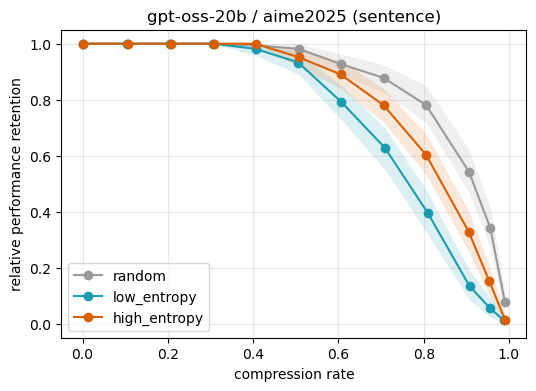

In [6]:
plot_curves(
    dataset="aime2025",
    model="gpt-oss-20b",
    selectors=["random", "low_entropy", "high_entropy"],
    level="sentence",
    patch=False,
    # save="figures/gptoss20b_aime2025_sentence.pdf",
)


## 5. Multi-panel plotting: dataset strip and full model x dataset grid

In [7]:
def plot_dataset_strip(model, datasets, selectors=["random", "low_entropy", "high_entropy"],
                        level="sentence", patch=False, ncols=None, save=None):
    ncols = ncols or len(datasets)
    nrows = int(np.ceil(len(datasets) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.2 * nrows), sharey=True)
    axes = np.atleast_1d(axes).flatten()

    for ax, dataset in zip(axes, datasets):
        plot_curves(
            dataset=dataset, model=model, selectors=selectors,
            level=level, patch=patch, ax=ax,
            title=dataset,
        )
        ax.get_legend().remove()
        ax.set_ylabel("")

    for ax in axes[len(datasets):]:
        ax.axis("off")

    fig.text(0.0, 0.5, "relative performance retention", va="center", rotation="vertical")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(selectors),
               bbox_to_anchor=(0.5, 1.06))
    fig.suptitle(f"{model} ({level}{', patch' if patch else ''})", y=1.14)
    fig.tight_layout()

    if save:
        Path(save).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save, dpi=600, bbox_inches="tight")
    plt.show()


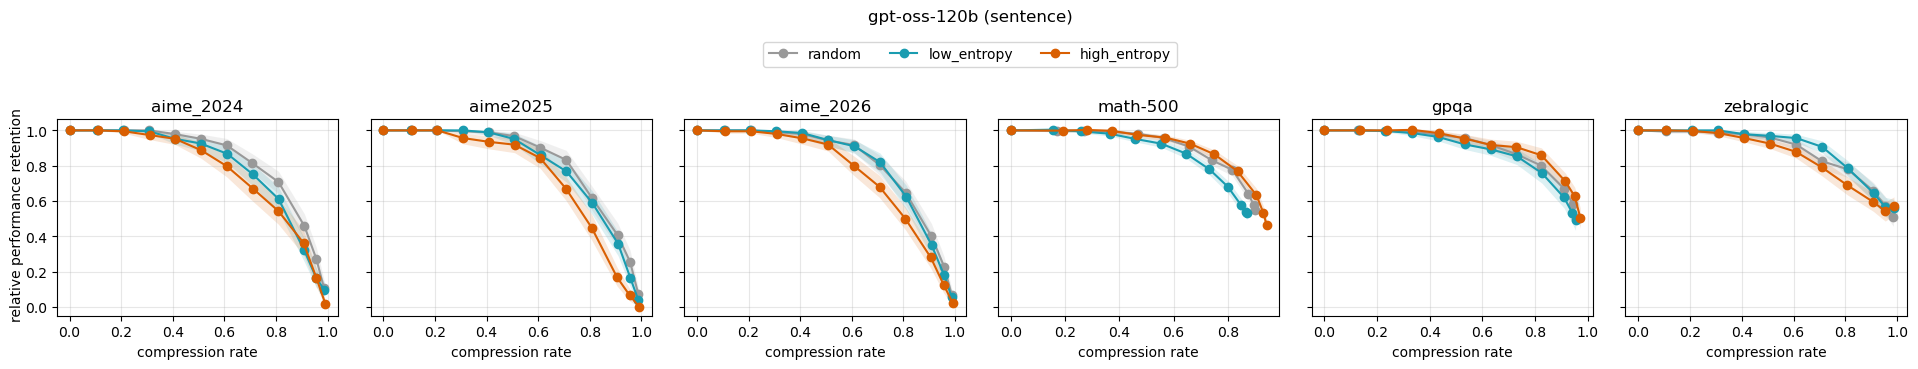

In [8]:
plot_dataset_strip(
    model="gpt-oss-120b",
    datasets=DATASETS,
    level="sentence",
    # save="figures/appendix_strip_gptoss20b_sentence.pdf",
)

In [9]:
def plot_full_grid(models, datasets, selectors=["random", "low_entropy", "high_entropy"],
                    level="sentence", patch=False, save=None):
    nrows, ncols = len(models), len(datasets)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 2.6 * nrows), sharex=True, sharey=True)
    axes = np.asarray(axes).reshape(nrows, ncols)
    for i, model in enumerate(models):
        for j, dataset in enumerate(datasets):
            ax = axes[i, j]
            plot_curves(
                dataset=dataset, model=model, selectors=selectors,
                level=level, patch=patch, ax=ax,
            )
            ax.set_title("")
            ax.get_legend().remove()
            ax.set_ylabel("")
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelsize=8, rotation=45)
            if i == 0:
                ax.set_title(DATASET_LABELS.get(dataset, dataset))
            if j == 0:
                ax.set_ylabel(model, fontsize=10)

    fig.tight_layout(rect=[0.04, 0.03, 1, 1])
    fig.text(0.0, 0.5, "relative performance retention", va="center", rotation="vertical")
    fig.text(0.5, 0.0, "compression rate", ha="center")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(selectors),
               bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f"{level}{', patch' if patch else ''}", y=1.05)

    if save:
        Path(save).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save, dpi=600, bbox_inches="tight")
    plt.show()


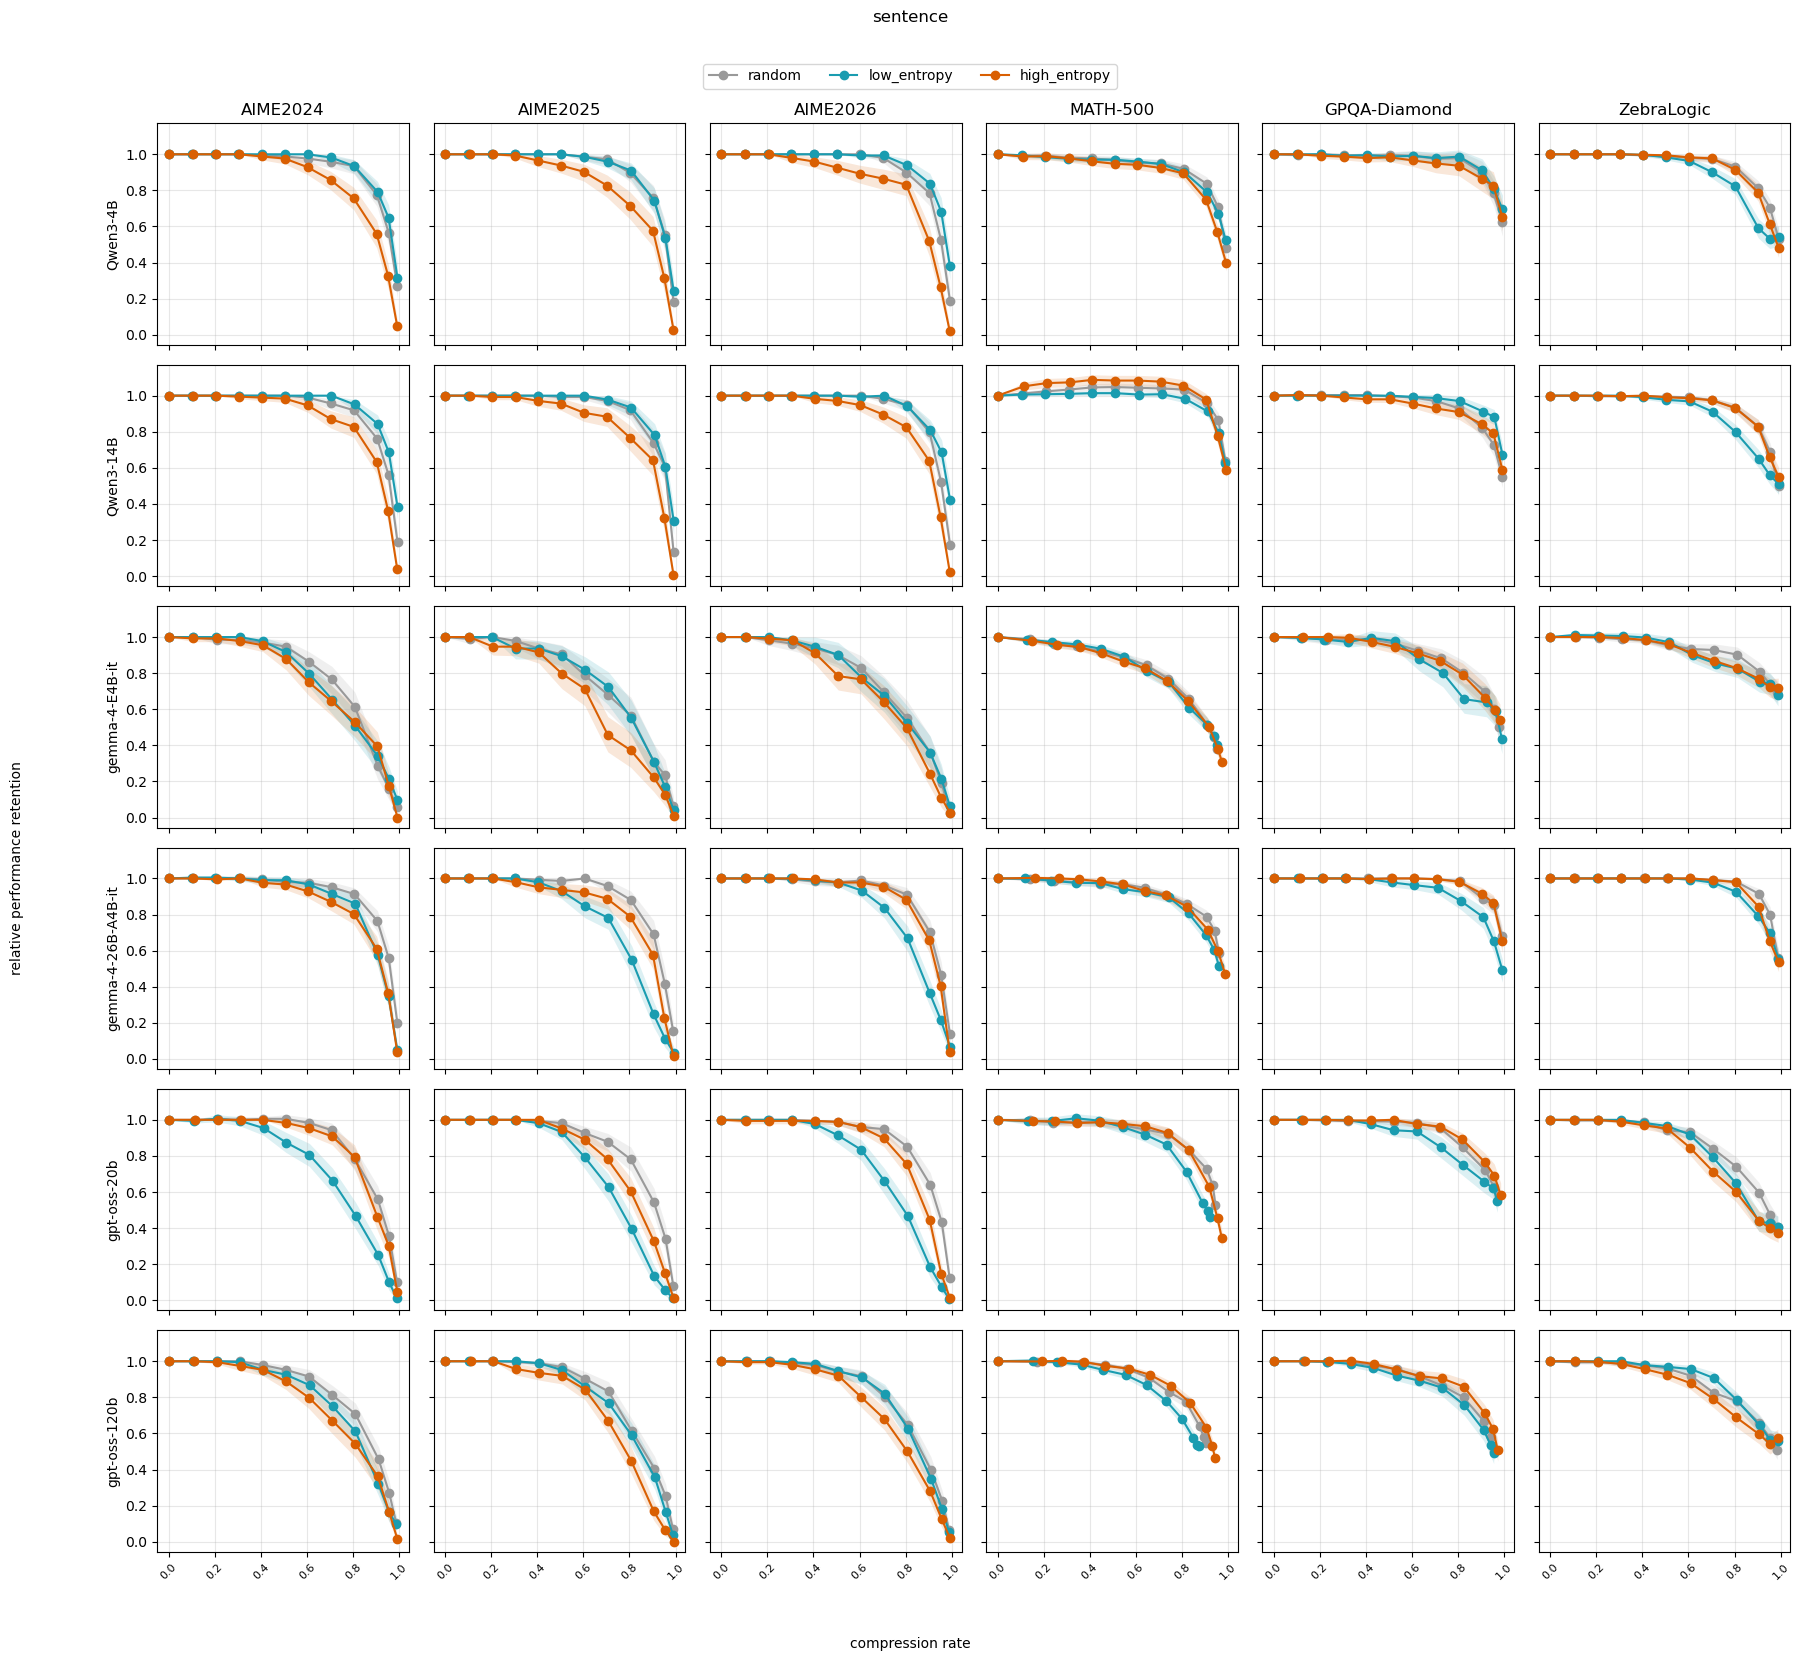

In [10]:
plot_full_grid(
    models=MODELS,
    datasets=DATASETS,
    level="sentence",
    # save="figures/appendix_full_grid_sentence_no_numbers.pdf",
)

## 6. AUC / delta-AUC table (sentence-level)

In [11]:
def find_sentence_files(data_dir: Path):
    files = []
    for dataset in DATASETS:
        d = data_dir / dataset / "results_sentence"
        if not d.exists():
            continue
        for f in d.glob("*_eval_sentence_*_nopatch.json"):
            files.append((dataset, f))
    return files


def load_raw_sentence_records(data_dir: Path):
    """One row = one trace: (model, dataset, selector, rate, trace_id) ->
    reached_correct, full_correct. trace_id = (question_id, trace_index)."""
    files = find_sentence_files(data_dir)
    rows = []
    for dataset, fpath in files:
        try:
            d = json.load(open(fpath))
        except Exception as e:
            print(f"SKIP {fpath}: {e}")
            continue
        model = d.get("model", "?").split("/")[-1]
        selector = d.get("selector", "?")
        rate = d.get("retention_rate", None)
        results = d.get("results", [])
        if rate is None or not results:
            continue
        for r in results:
            trace = r.get("trace", {})
            rc = trace.get("reached_only", {}).get("correct")
            fc = trace.get("full_sequence", {}).get("correct")
            if rc is None or fc is None:
                continue
            rows.append({
                "model": model, "dataset": dataset, "selector": selector,
                "rate": rate,
                "trace_id": (r.get("question_id"), trace.get("trace_index")),
                "reached_correct": int(bool(rc)), "full_correct": int(bool(fc)),
            })
    return pd.DataFrame(rows)


raw_sentence = load_raw_sentence_records(ROOT)


def _prep_selector(sub, trace_ids):
    """Precomputes numpy arrays for a single model/dataset/selector combo,
    ready to be aggregated quickly at every bootstrap resample."""
    tid_to_idx = {t: i for i, t in enumerate(trace_ids)}
    rates = np.sort(sub["rate"].unique())
    rate_to_col = {r: i for i, r in enumerate(rates)}
    t_idx = sub["trace_id"].map(tid_to_idx).to_numpy()
    r_idx = sub["rate"].map(rate_to_col).to_numpy()
    reached = sub["reached_correct"].to_numpy(dtype=float)
    full = sub["full_correct"].to_numpy(dtype=float)
    return t_idx, r_idx, reached, full, rates


def _auc_from_counts(counts, t_idx, r_idx, reached, full, rates):
    """counts: array (n_trace_ids,) with the number of times each trace_id
    was resampled in the current draw (all-ones counts = original data)."""
    w = counts[t_idx]
    n_rates = len(rates)
    reached_w = np.bincount(r_idx, weights=reached * w, minlength=n_rates)
    full_w = np.bincount(r_idx, weights=full * w, minlength=n_rates)
    w_sum = np.bincount(r_idx, weights=w, minlength=n_rates)

    valid = w_sum > 0
    safe_w = np.where(valid, w_sum, 1.0)
    rel_pr = reached_w / safe_w
    full_mean = full_w / safe_w
    valid = valid & (full_mean > 0)

    if valid.sum() == 0:
        return np.nan
    return np.trapz(rel_pr[valid], rates[valid])


def bootstrap_delta_auc(raw, model, dataset, selector_a, selector_b="random",
                         patched=None, n_boot=1000, seed=0):
    """Trace-level bootstrap CI, same resample reused across all rates and
    both selectors (preserves correlation). Vectorized numpy version: no
    DataFrame operations inside the bootstrap loop."""
    base = raw[(raw.model == model) & (raw.dataset == dataset)]
    if patched is not None:
        base = base[base.patched == patched]
    sub_a = base[base.selector == selector_a]
    sub_b = base[base.selector == selector_b]
    if sub_a.empty or sub_b.empty:
        return None

    trace_ids = sorted(base.trace_id.unique(), key=str)
    n = len(trace_ids)
    if n == 0:
        return None

    ta_idx, ra_idx, reached_a, full_a, rates_a = _prep_selector(sub_a, trace_ids)
    tb_idx, rb_idx, reached_b, full_b, rates_b = _prep_selector(sub_b, trace_ids)

    ones = np.ones(n)
    point = (_auc_from_counts(ones, ta_idx, ra_idx, reached_a, full_a, rates_a)
              - _auc_from_counts(ones, tb_idx, rb_idx, reached_b, full_b, rates_b))

    rng = np.random.default_rng(seed)
    boots = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        counts = np.bincount(idx, minlength=n).astype(float)
        auc_a = _auc_from_counts(counts, ta_idx, ra_idx, reached_a, full_a, rates_a)
        auc_b = _auc_from_counts(counts, tb_idx, rb_idx, reached_b, full_b, rates_b)
        boots[i] = auc_a - auc_b

    boots = boots[~np.isnan(boots)]
    if len(boots) == 0:
        return point, np.nan, np.nan
    lo, hi = np.percentile(boots, [5, 95])
    return point, lo, hi
sentence_results = []
for model in sorted(raw_sentence.model.unique()):
    for dataset in ["aime2025", "zebralogic"]:
        for sel in ["low_entropy", "high_entropy"]:
            res = bootstrap_delta_auc(raw_sentence, model, dataset, sel)
            if res is None:
                continue
            point, lo, hi = res
            sentence_results.append({
                "model": model, "dataset": dataset, "selector": sel,
                "delta_auc": point, "ci_lo": lo, "ci_hi": hi,
            })

sentence_delta_ci = pd.DataFrame(sentence_results)
sentence_delta_ci


,model,dataset,selector,delta_auc,ci_lo,ci_hi
0,Qwen3-14B,aime2025,low_entropy,0.010000,-0.004965,0.026051
1,Qwen3-14B,aime2025,high_entropy,-0.060629,-0.081017,-0.041430
2,Qwen3-14B,zebralogic,low_entropy,-0.040714,-0.051267,-0.030479
3,Qwen3-14B,zebralogic,high_entropy,-0.000797,-0.007390,0.006198
4,Qwen3-4B,aime2025,low_entropy,-0.000691,-0.017043,0.016188
5,Qwen3-4B,aime2025,high_entropy,-0.074770,-0.097273,-0.054602
6,Qwen3-4B,zebralogic,low_entropy,-0.041922,-0.051362,-0.031100
7,Qwen3-4B,zebralogic,high_entropy,-0.006868,-0.014640,0.001161
8,gemma-4-26B-A4B-it,aime2025,low_entropy,-0.122535,-0.147079,-0.098623
9,gemma-4-26B-A4B-it,aime2025,high_entropy,-0.055035,-0.076620,-0.032389


## 7. Normalized-AUC delta table

**NOTE (unresolved in the source notebook):** `build_auc_delta_table` below still
references `SELECTOR_COLS`, which is never defined anywhere in the original notebook.
Running this cell as-is will raise `NameError`. Define it explicitly (e.g. to the
sentence-level selectors minus `random`) before running.

`_relative_pr_curve`, which was missing in the version you sent, has been restored
below from an earlier version of the analysis found in chat history (source: "Test
d'ipotesi per confrontare distribuzioni").

In [12]:
SELECTOR_COLS = ["low_entropy", "high_entropy"]  # o l'elenco completo se serve anche per numbers/ecc.

def _relative_pr_curve(sub, weights=None, rate_col="rate"):
    """Returns the (rate, relative_pr) curve, sorted, weighting each row by
    `weights` if given (resample counts) otherwise weight 1 per row."""
    s = sub.copy()
    s["w"] = 1.0 if weights is None else s["trace_id"].map(weights).fillna(0)
    s = s[s["w"] > 0]
    if s.empty:
        return None
    per_rate = s.groupby(rate_col).apply(
        lambda g: pd.Series({
            "reached_mean": np.average(g["reached_correct"], weights=g["w"]),
            "full_mean": np.average(g["full_correct"], weights=g["w"]),
        })
    ).reset_index()
    per_rate = per_rate[per_rate["full_mean"] > 0]
    if per_rate.empty:
        return None
    per_rate["relative_pr"] = per_rate["reached_mean"] / per_rate["full_mean"]
    return per_rate.sort_values(rate_col)


def auc_in_range_normalized(sub, rate_min, rate_max):
    s = sub[(sub["rate"] >= rate_min) & (sub["rate"] <= rate_max)]
    curve = _relative_pr_curve(s)
    if curve is None:
        return np.nan
    raw_auc = np.trapz(curve["relative_pr"], curve["rate"])
    width = curve["rate"].max() - curve["rate"].min()
    if width == 0:
        return np.nan
    return raw_auc / width


def build_auc_delta_table(raw):
    rows = []
    for model in MODELS:
        for dataset in DATASETS:
            base = raw[(raw.model == model) & (raw.dataset == dataset)]
            if base.empty:
                rows.append({"model": model, "dataset": dataset, "missing": True})
                continue

            row = {"model": model, "dataset": dataset, "missing": False}
            for rng_name, (lo, hi) in [("full", (0.01, 1.0)), ("agg", (0.01, 0.3))]:
                rand_auc = auc_in_range_normalized(base[base.selector == "random"], lo, hi)
                row[f"rand_{rng_name}"] = rand_auc
                for sel in SELECTOR_COLS:  # FIXME: undefined in the source notebook, see note above
                    sel_auc = auc_in_range_normalized(base[base.selector == sel], lo, hi)
                    row[f"d_{sel}_{rng_name}"] = sel_auc - rand_auc
            rows.append(row)
    return pd.DataFrame(rows)


auc_table = build_auc_delta_table(raw_sentence)
auc_table


/tmp/ipykernel_5536/1209660496.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_rate = s.groupby(rate_col).apply(
/tmp/ipykernel_5536/1209660496.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_rate = s.groupby(rate_col).apply(
/tmp/ipykernel_5536/1209660496.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future versio

,model,dataset,missing,rand_full,d_low_entropy_full,d_high_entropy_full,rand_agg,d_low_entropy_agg,d_high_entropy_agg
0,Qwen3-4B,aime_2024,False,0.933291,0.012716,-0.066378,0.793822,0.024938,-0.186576
1,Qwen3-4B,aime2025,False,0.930100,-0.000737,-0.079721,0.770953,-0.000120,-0.182352
2,Qwen3-4B,aime_2026,False,0.933456,0.019758,-0.078351,0.776328,0.067451,-0.163793
3,Qwen3-4B,math-500,False,0.936744,-0.007727,-0.025759,0.839607,-0.022128,-0.063046
4,Qwen3-4B,gpqa,False,0.967236,0.004344,-0.013397,0.902762,0.015561,-0.019433
5,Qwen3-4B,zebralogic,False,0.949799,-0.045136,-0.007395,0.844926,-0.133337,-0.028703
6,Qwen3-14B,aime_2024,False,0.932050,0.024461,-0.047639,0.779217,0.072321,-0.121622
7,Qwen3-14B,aime2025,False,0.932095,0.010543,-0.063924,0.778253,0.029700,-0.145230
8,Qwen3-14B,aime_2026,False,0.939188,0.013918,-0.055056,0.795409,0.046512,-0.138833
9,Qwen3-14B,math-500,False,1.011761,-0.030464,0.027194,0.961842,-0.046984,0.002507


# TOKEN-LEVEL

In [13]:
def find_token_files(data_dir: Path):
    files = []
    for dataset in DATASETS:
        d = data_dir / dataset / "results"
        if not d.exists():
            continue
        for f in d.glob("*_eval_*.json"):
            if "_eval_sentence_" in f.name:
                continue  # excludes sentence-level files
            files.append((dataset, f))
    return files


def load_raw_token_records(data_dir: Path):
    """One row = one (trace, patched-condition): (model, dataset, selector, rate,
    trace_id, patched) -> reached_correct, full_correct. At the token level,
    surface and patched live in the same file/trace: both are emitted here as
    separate rows carrying an explicit `patched` flag, instead of picking one
    at load time."""
    files = find_token_files(data_dir)
    rows = []
    for dataset, fpath in files:
        try:
            d = json.load(open(fpath))
        except Exception as e:
            print(f"SKIP {fpath}: {e}")
            continue

        model = d.get("model", "?").split("/")[-1]
        selector = d.get("selector", "?")
        rate = d.get("retention_rate", None)
        results = d.get("results", [])
        if rate is None or not results:
            continue

        for r in results:
            trace = r.get("trace", {})
            if "full_sequence" not in trace:
                continue
            fc = trace["full_sequence"].get("correct")
            if fc is None:
                continue
            trace_id = (r.get("question_id"), trace.get("trace_index"))

            for patched, key in [(False, "reached_only"), (True, "reached_patched")]:
                if key not in trace:
                    continue
                rc = trace[key].get("correct")
                if rc is None:
                    continue
                rows.append({
                    "model": model, "dataset": dataset, "selector": selector,
                    "rate": rate, "trace_id": trace_id, "patched": patched,
                    "reached_correct": int(bool(rc)), "full_correct": int(bool(fc)),
                })
    return pd.DataFrame(rows)


raw_token = load_raw_token_records(ROOT)
raw_token.shape

(1915224, 8)

In [14]:
TOKEN_SELECTOR_COLS = ["low_entropy", "high_entropy", "numbers", "end_of_sentence", "newlines", "low_entropy_no_numbers"]

token_results = []
for model in sorted(raw_token.model.unique()):
    for dataset in ["aime2025", "zebralogic"]:
        for sel in TOKEN_SELECTOR_COLS:
            res = bootstrap_delta_auc(raw_token, model, dataset, sel)
            if res is None:
                continue
            point, lo, hi = res
            token_results.append({
                "model": model, "dataset": dataset, "selector": sel,
                "delta_auc": point, "ci_lo": lo, "ci_hi": hi,
            })

token_delta_ci = pd.DataFrame(token_results)
token_delta_ci


,model,dataset,selector,delta_auc,ci_lo,ci_hi
0,Qwen3-14B,aime2025,low_entropy,0.166451,0.151691,0.181190
1,Qwen3-14B,aime2025,high_entropy,-0.406783,-0.430963,-0.385517
2,Qwen3-14B,aime2025,numbers,-0.239213,-0.252448,-0.225889
3,Qwen3-14B,aime2025,end_of_sentence,-0.707133,-0.728602,-0.684735
4,Qwen3-14B,aime2025,newlines,-0.707133,-0.728602,-0.684735
...,...,...,...,...,...,...
64,gpt-oss-20b,zebralogic,high_entropy,-0.106923,-0.121087,-0.093087
65,gpt-oss-20b,zebralogic,numbers,-0.429515,-0.462573,-0.392395
66,gpt-oss-20b,zebralogic,end_of_sentence,-0.313838,-0.343334,-0.282488
67,gpt-oss-20b,zebralogic,newlines,-0.380221,-0.414408,-0.344981


In [15]:
token_delta_ci[
    (token_delta_ci["dataset"] == "aime2025") &
    (token_delta_ci["selector"].isin(["low_entropy", "numbers", "low_entropy_no_numbers"]))
].sort_values(["model", "selector"])

,model,dataset,selector,delta_auc,ci_lo,ci_hi
0,Qwen3-14B,aime2025,low_entropy,0.166451,0.151691,0.181190
5,Qwen3-14B,aime2025,low_entropy_no_numbers,-0.646766,-0.677555,-0.616242
2,Qwen3-14B,aime2025,numbers,-0.239213,-0.252448,-0.225889
12,Qwen3-4B,aime2025,low_entropy,0.157220,0.141346,0.172797
17,Qwen3-4B,aime2025,low_entropy_no_numbers,-0.658816,-0.681996,-0.631595
14,Qwen3-4B,aime2025,numbers,-0.187845,-0.205412,-0.169340
24,gemma-4-26B-A4B-it,aime2025,low_entropy,0.118375,0.091550,0.141941
26,gemma-4-26B-A4B-it,aime2025,numbers,-0.192322,-0.210385,-0.174209
34,gemma-4-E4B-it,aime2025,low_entropy,0.070638,0.056547,0.085147
39,gemma-4-E4B-it,aime2025,low_entropy_no_numbers,-0.201998,-0.233354,-0.174752


In [16]:
raw_token[
    (raw_token.model == "gpt-oss-120b") &
    (raw_token.dataset == "gpqa") &
    (raw_token.selector.isin(["low_entropy", "numbers", "low_entropy_no_numbers"]))
].selector.unique()

array(['numbers', 'low_entropy', 'low_entropy_no_numbers'], dtype=object)

In [17]:
records_all = []
for level in ["token", "sentence"]:
    for dataset in DATASETS:
        for model in MODELS:
            for sel in SELECTOR_COLORS.keys():
                if sel == "random":
                    continue
                patch_values = [False, True] if level == "token" else [False]
                for patch in patch_values:
                    xs, ys, los, his = get_curve_with_ci(dataset, model, sel, level=level, patch=patch)
                    for x, y, lo, hi in zip(xs, ys, los, his):
                        if y > 1.0:  # any point above full-CoT, regardless of CI
                            records_all.append({
                                "level": level, "dataset": dataset, "model": model,
                                "selector": sel, "patch": patch,
                                "compression_rate": round(1 - x, 3),
                                "point": round(y, 3), "ci_lo": round(lo, 3), "ci_hi": round(hi, 3),
                                "ci_excludes_1": lo > 1.0,
                            })

above_full_all = pd.DataFrame(records_all)
above_full_all = above_full_all.sort_values(["level","dataset","model","selector","compression_rate"])
print(f"{len(above_full_all)} points with point > 1.0 (of which {above_full_all.ci_excludes_1.sum()} have CI entirely above 1.0)")
print()
print(above_full_all.groupby(["level","selector"]).agg(
    n=("point","size"), n_significant=("ci_excludes_1","sum"), mean_point=("point","mean")
))
above_full_all

177 points with point > 1.0 (of which 40 have CI entirely above 1.0)

                                  n  n_significant  mean_point
level    selector                                             
sentence high_entropy            12              8    1.049833
         low_entropy             15              3    1.008067
         low_entropy_no_numbers  15              4    1.008467
         numbers                 20              5    1.015100
token    high_entropy            22              4    1.016000
         low_entropy             51              7    1.018412
         low_entropy_no_numbers   5              0    1.004400
         numbers                 37              9    1.030757


,level,dataset,model,selector,patch,compression_rate,point,ci_lo,ci_hi,ci_excludes_1
116,sentence,aime_2024,gemma-4-26B-A4B-it,low_entropy,False,0.102,1.005,1.000,1.015,False
115,sentence,aime_2024,gemma-4-26B-A4B-it,low_entropy,False,0.202,1.005,1.000,1.015,False
124,sentence,aime_2024,gemma-4-26B-A4B-it,low_entropy_no_numbers,False,0.102,1.005,1.000,1.015,False
123,sentence,aime_2024,gemma-4-26B-A4B-it,low_entropy_no_numbers,False,0.203,1.005,1.000,1.015,False
122,sentence,aime_2024,gemma-4-26B-A4B-it,low_entropy_no_numbers,False,0.304,1.005,1.000,1.015,False
...,...,...,...,...,...,...,...,...,...,...
102,token,zebralogic,gpt-oss-120b,low_entropy,False,0.400,1.003,0.995,1.014,False
106,token,zebralogic,gpt-oss-120b,low_entropy,True,0.400,1.005,1.000,1.014,False
105,token,zebralogic,gpt-oss-120b,low_entropy,True,0.500,1.003,1.000,1.008,False
104,token,zebralogic,gpt-oss-120b,low_entropy,True,0.600,1.014,1.003,1.028,True


In [18]:
sent_he = above_full_all[(above_full_all.level=="sentence") & (above_full_all.selector=="high_entropy")]
print(sent_he[["dataset","model","compression_rate","point","ci_lo","ci_hi","ci_excludes_1"]].to_string(index=False))

 dataset              model  compression_rate  point  ci_lo  ci_hi  ci_excludes_1
    gpqa          Qwen3-14B             0.107  1.003  1.000  1.011          False
    gpqa       gpt-oss-120b             0.334  1.003  1.000  1.010          False
math-500          Qwen3-14B             0.114  1.052  1.031  1.073           True
math-500          Qwen3-14B             0.214  1.070  1.045  1.095           True
math-500          Qwen3-14B             0.314  1.074  1.050  1.100           True
math-500          Qwen3-14B             0.412  1.088  1.061  1.116           True
math-500          Qwen3-14B             0.511  1.084  1.056  1.112           True
math-500          Qwen3-14B             0.609  1.084  1.055  1.112           True
math-500          Qwen3-14B             0.708  1.078  1.049  1.108           True
math-500          Qwen3-14B             0.806  1.056  1.024  1.088           True
math-500 gemma-4-26B-A4B-it             0.161  1.003  0.993  1.014          False
math-500       g

## 8. Token-level full grid plots

**NOTE:** the two calls below use different, deliberately distinct model orderings
(`MODELS` -- the canonical order from cell 1 -- vs `MODELS_TOKEN_GRID`, matching the
order used for these specific appendix figures in the source notebook). Kept as
separate constants rather than merged, since the ordering difference looked
intentional rather than a typo.

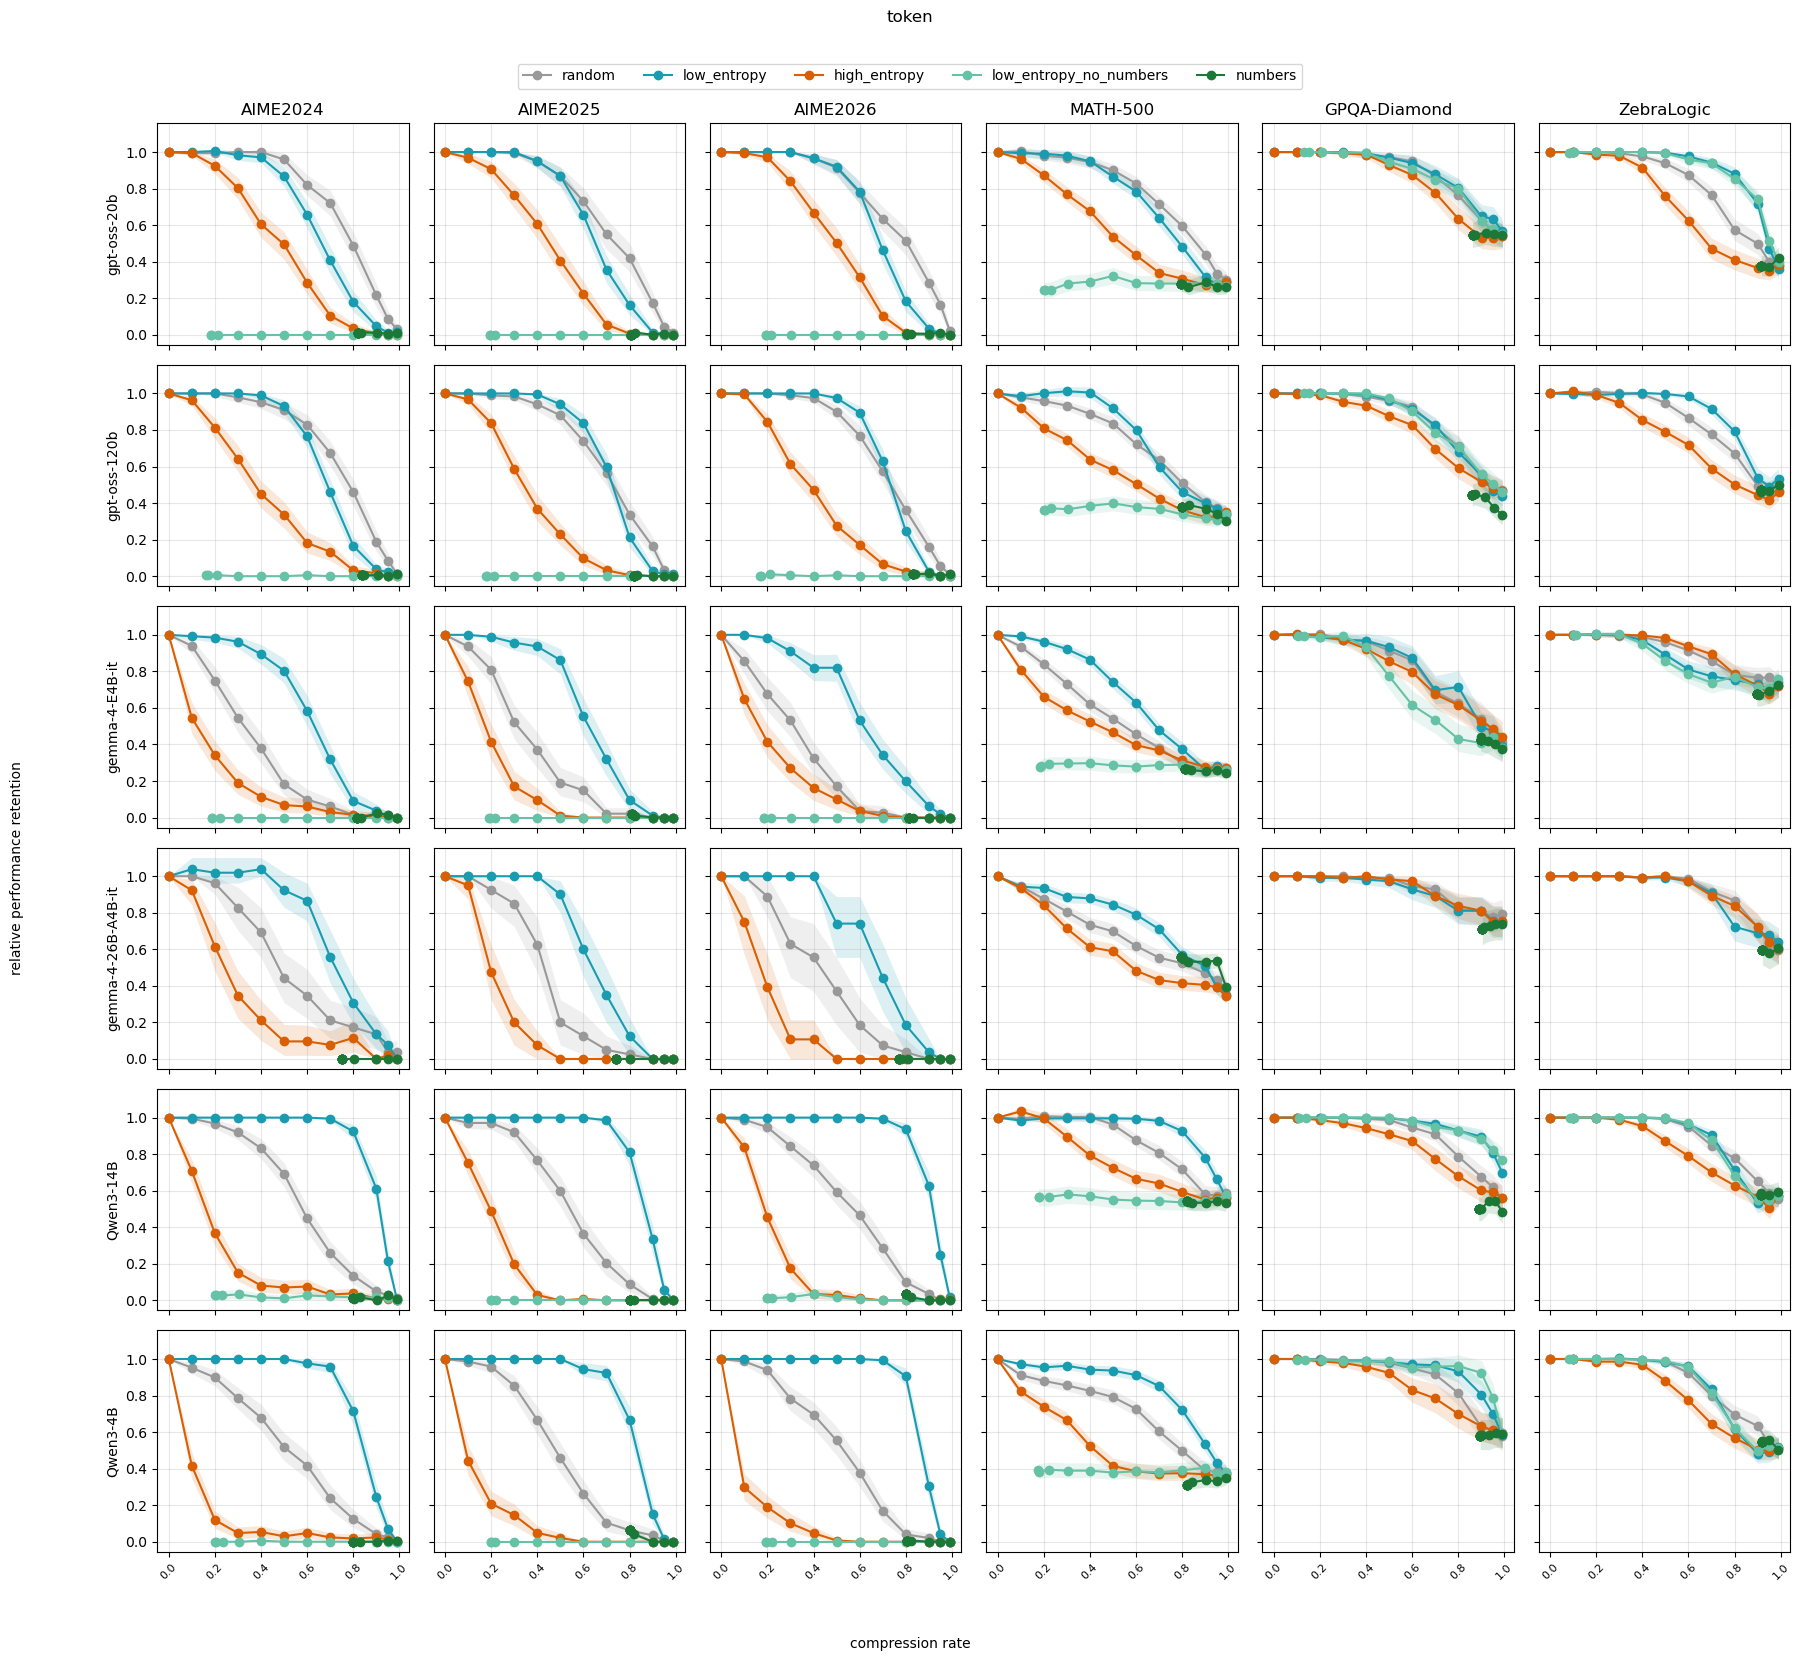

In [19]:
MODELS_TOKEN_GRID = ["gpt-oss-20b", "gpt-oss-120b", "gemma-4-E4B-it", "gemma-4-26B-A4B-it", "Qwen3-14B", "Qwen3-4B"]

TOKEN_SELECTORS_TO_PLOT = ["random", "low_entropy", "high_entropy", "low_entropy_no_numbers", "numbers"]

plot_full_grid(
    models=MODELS_TOKEN_GRID,
    datasets=DATASETS,
    selectors=TOKEN_SELECTORS_TO_PLOT,
    level="token",
    patch=False,
    # save="figures/appendix_full_grid_token.pdf",
)


In [20]:
def plot_lowent_no_numbers_ablation_figure(
    model="gpt-oss-120b",
    datasets=("math-500", "gpqa"),
    selectors=("random", "low_entropy", "numbers", "low_entropy_no_numbers"),
    level="token",
    save=None,
):
    """Two side-by-side panels, normal figure size, each panel narrow
    (taller than wide) rather than square. No title, compact legend,
    minimal top whitespace."""
    n = len(datasets)
    fig, axes = plt.subplots(
        1, n,
        figsize=(3.0 * n, 5.0),
        sharey=True,
    )
    axes = np.atleast_1d(axes)

    for ax, dataset in zip(axes, datasets):
        plot_curves(
            dataset=dataset, model=model, selectors=list(selectors),
            level=level, patch=False, ax=ax,
            title=DATASET_LABELS.get(dataset, dataset),
        )
        ax.get_legend().remove()
        ax.set_ylabel("")
        ax.set_xlabel("")

    axes[0].set_ylabel("relative performance retention")
    fig.text(0.5, 0.02, "compression rate", ha="center")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc="upper center", ncol=4,
        bbox_to_anchor=(0.5, 1.0), fontsize=8, frameon=False,
        handletextpad=0.3, columnspacing=0.8,
    )
    fig.tight_layout(rect=[0, 0.03, 1, 0.94])

    if save:
        Path(save).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save, dpi=600, bbox_inches="tight")
    plt.show()

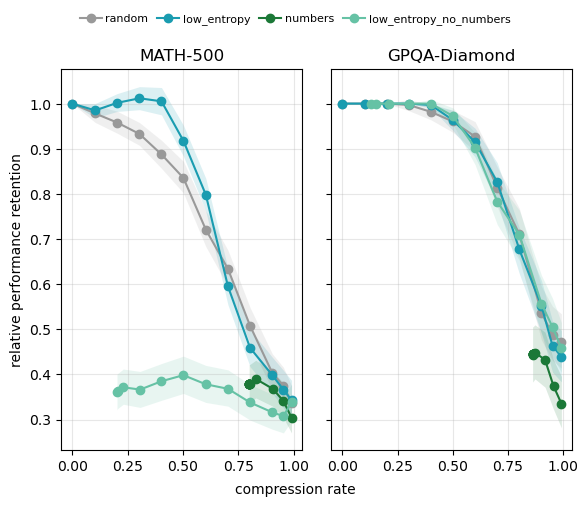

In [21]:
plot_lowent_no_numbers_ablation_figure(
    model="gpt-oss-120b",
    datasets=("math-500", "gpqa"),
    # save="figures/low_entropy_gptoss120b.pdf",
)

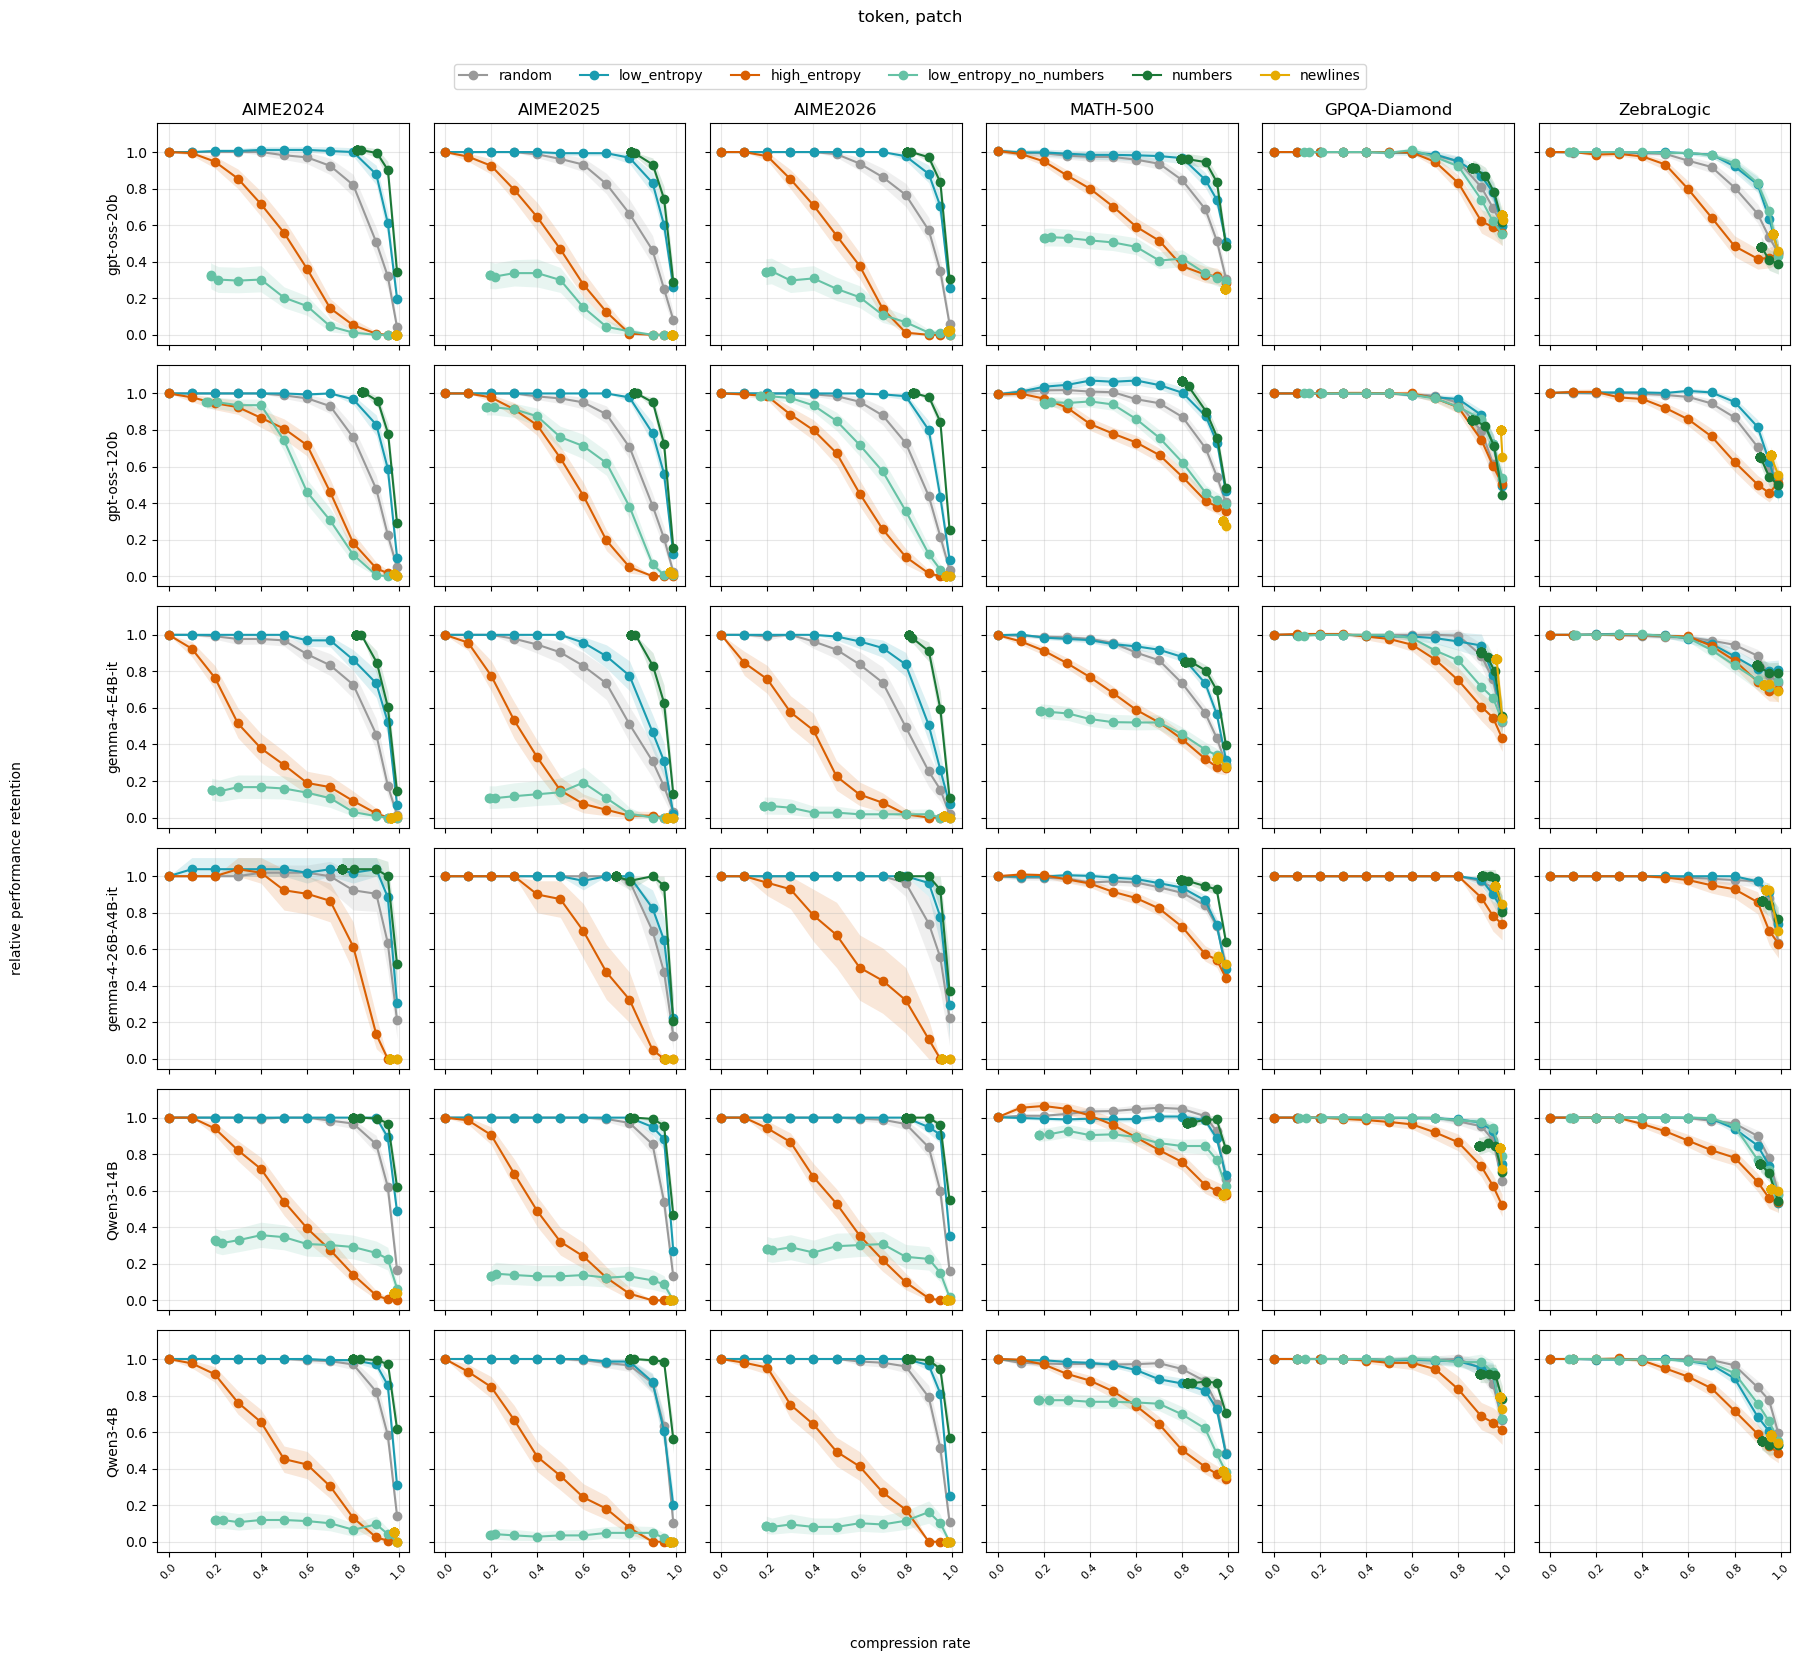

In [22]:
TOKEN_SELECTORS_TO_PLOT = ["random", "low_entropy", "high_entropy", "low_entropy_no_numbers", "numbers", "endofsentence", "newlines"]

plot_full_grid(
    models=MODELS_TOKEN_GRID,
    datasets=DATASETS,
    selectors=TOKEN_SELECTORS_TO_PLOT,
    level="token",
    patch=True,
    # save="figures/appendix_full_grid_token_patch.pdf",
)


In [23]:
TOKEN_SELECTOR_COLS = ["low_entropy", "high_entropy", "numbers", "end_of_sentence", "newlines", "low_entropy_no_numbers"]
DATASETS = ["aime2024", "aime2025", "aime2026", "math500", "gpqa", "zebralogic"]
PATCH_CONDITIONS = [False, True]

token_results = []
for model in sorted(raw_token.model.unique()):
    for dataset in DATASETS:
        for patched in PATCH_CONDITIONS:
            for sel in TOKEN_SELECTOR_COLS:
                res = bootstrap_delta_auc(raw_token, model, dataset, sel, patched=patched)
                if res is None:
                    continue
                point, lo, hi = res
                token_results.append({
                    "model": model, "dataset": dataset, "patched": patched,
                    "selector": sel, "delta_auc": point, "ci_lo": lo, "ci_hi": hi,
                })

token_delta_ci = pd.DataFrame(token_results)

In [41]:
def plot_model_strip(dataset, models, selectors=["random", "low_entropy", "high_entropy"],
                      level="token", patch=False, ncols=None, save=None):
    ncols = ncols or len(models)
    nrows = int(np.ceil(len(models) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.5 * ncols, 4 * nrows), sharey=True)
    axes = np.atleast_1d(axes).flatten()

    for ax, model in zip(axes, models):
        plot_curves(
            dataset=dataset, model=model, selectors=selectors,
            level=level, patch=patch, ax=ax,
            title=model,
        )
        ax.get_legend().remove()
        ax.set_ylabel("")

    for ax in axes[len(models):]:
        ax.axis("off")

    fig.text(0.0, 0.5, "relative performance retention", va="center", rotation="vertical")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(selectors),
               bbox_to_anchor=(0.5, 1.06))
    fig.suptitle(f"{dataset} ({level}{', patch' if patch else ''})", y=1.14)
    fig.tight_layout()

    if save:
        Path(save).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save, dpi=600, bbox_inches="tight")
    plt.show()

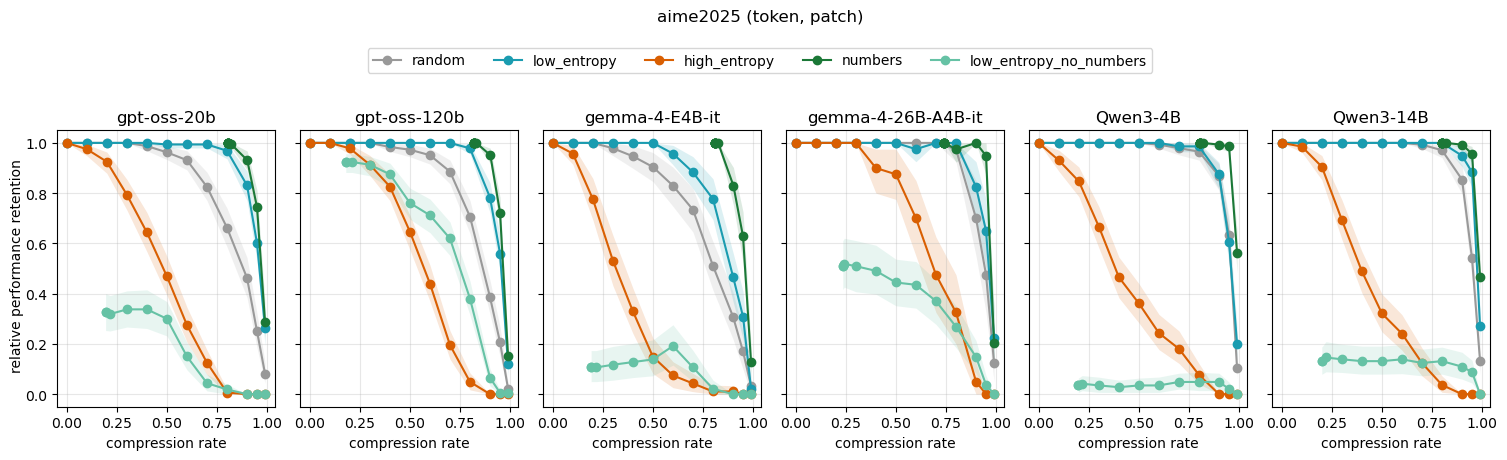

In [42]:
plot_model_strip(
    dataset="aime2025",
    models=["gpt-oss-20b", "gpt-oss-120b", "gemma-4-E4B-it", "gemma-4-26B-A4B-it", "Qwen3-4B", "Qwen3-14B"],
    selectors=["random", "low_entropy", "high_entropy", "numbers", "low_entropy_no_numbers"],
    level="token", patch=True,
    save="figs/partial_aime2025_patched_strip.pdf",
)

## 10. Appendix: math_verify-based semantic matching (skip_patched=True files only)

The cells below do NOT modify any file on disk. They recompute correctness
in-memory from the already-saved `generated_answer` strings (re-adding
`suffix_text`, since that's what was actually fed to `check_correct` at
generation time and what any \boxed{{}} extraction depends on).

Restricted to `skip_patched=True` files: those never have
`reached_patched`/`random_patched` keys, so every condition present
(`full_sequence`, `reached_only`, `random_only`, `no_cot`) has a saved
`generated_answer` and can be fully re-verified. This is intended as an
appendix-only robustness check, run on both sentence- and token-level
sweeps that used `--skip_patched True`.

In [26]:
import sys as _sys

# Make entropy.core.utils importable regardless of where this notebook's
# cwd happens to be relative to the repo root.
for _candidate in [Path("..").resolve(), Path(".").resolve(), Path("../..").resolve()]:
    if (_candidate / "entropy" / "core" / "utils.py").exists():
        if str(_candidate) not in _sys.path:
            _sys.path.insert(0, str(_candidate))
        break

from entropy.core.utils import check_correct

MCQ_DATASETS = {"gpqa", "zebralogic"}

def answer_domain_for(dataset):
    return "mcq" if dataset in MCQ_DATASETS else "math"


In [27]:
def per_trace_correctness_semantic(data, dataset, patch=False):
    """Semantic-match version of per_trace_correctness. Only meaningful
    for skip_patched=True files (no reached_patched/random_patched keys),
    where every condition has a saved generated_answer we can re-verify.
    Re-adds suffix_text before check_correct, since that's what was
    actually fed to check_correct at generation time (extract_boxed_answer
    needs the opening brace that lives in suffix_text, not in
    generated_answer alone)."""
    key = "reached_patched" if patch else "reached_only"
    domain = answer_domain_for(dataset)
    suffix_text = data.get("suffix_text", "")
    sel, full = [], []
    for item in data["results"]:
        tr = item["trace"]
        gt = str(item["GT_answer"])
        if key not in tr or "full_sequence" not in tr:
            continue

        sel_block = tr[key]
        if "generated_answer" in sel_block:
            sel_correct = check_correct(suffix_text + sel_block["generated_answer"], gt, answer_domain=domain)
        else:
            sel_correct = bool(sel_block["correct"])

        full_gen = tr["full_sequence"].get("generated_answer")
        if full_gen is not None:
            full_correct = check_correct(suffix_text + full_gen, gt, answer_domain=domain)
        else:
            full_correct = bool(tr["full_sequence"]["correct"])

        sel.append(int(sel_correct))
        full.append(int(full_correct))
    return np.array(sel), np.array(full)


def get_curve_with_ci_semantic(dataset, model, selector, level="token", patch=False):
    loader = load_token_json if level == "token" else load_sentence_json
    xs, ys, los, his = [], [], [], []
    for rate in RATES:
        data = loader(dataset, model, selector, rate)
        if data is None:
            continue
        sel, full = per_trace_correctness_semantic(data, dataset, patch=(patch if level == "token" else False))
        point, lo, hi = bootstrap_relative_pr(sel, full)
        if point is None:
            continue

        actual_retentions = []
        for item in data["results"]:
            tr = item["trace"]
            nr = tr.get("n_tokens_reached")
            nt = tr.get("n_tokens_thinking")
            if nr is not None and nt:
                actual_retentions.append(nr / nt)
        actual_retention = np.mean(actual_retentions) if actual_retentions else float(rate)

        xs.append(actual_retention); ys.append(point); los.append(lo); his.append(hi)

    xs = np.array(xs)
    order = np.argsort(xs)
    return xs[order], np.array(ys)[order], np.array(los)[order], np.array(his)[order]


In [28]:
def plot_curves_semantic(dataset, model, selectors, level="token", patch=False,
                          x_axis="compression", title=None, ax=None):
    """Same as plot_curves, but using math_verify-based semantic matching
    instead of the stored (exact-match) correct flags. Appendix use only:
    valid for skip_patched=True files (no patched conditions to fall back on)."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(6, 4))
    for sel in selectors:
        xs, ys, los, his = get_curve_with_ci_semantic(dataset, model, sel, level=level, patch=patch)
        if len(xs) == 0:
            continue
        if x_axis == "compression":
            xs = 1 - xs
        color = SELECTOR_COLORS.get(sel, None)
        ax.plot(xs, ys, marker="o", label=sel, color=color)
        ax.fill_between(xs, los, his, color=color, alpha=0.15, linewidth=0)
    ax.set_xlabel("compression rate" if x_axis == "compression" else "retention rate")
    ax.set_ylabel("relative performance retention")
    ax.set_title(title or f"{model} / {dataset} ({level}, math_verify)")
    ax.legend()
    ax.grid(alpha=0.3)
    if standalone:
        plt.show()


def plot_full_grid_semantic(models, datasets, selectors=("random", "low_entropy", "high_entropy"),
                             level="token", save=None):
    nrows, ncols = len(models), len(datasets)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 2.6 * nrows), sharex=True, sharey=True)
    axes = np.asarray(axes).reshape(nrows, ncols)
    for i, model in enumerate(models):
        for j, dataset in enumerate(datasets):
            ax = axes[i, j]
            plot_curves_semantic(dataset=dataset, model=model, selectors=list(selectors),
                                  level=level, ax=ax)
            ax.set_title("")
            ax.get_legend().remove()
            ax.set_ylabel("")
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelsize=8, rotation=45)
            if i == 0:
                ax.set_title(DATASET_LABELS.get(dataset, dataset))
            if j == 0:
                ax.set_ylabel(model, fontsize=10)

    fig.tight_layout(rect=[0.04, 0.03, 1, 1])
    fig.text(0.0, 0.5, "relative performance retention", va="center", rotation="vertical")
    fig.text(0.5, 0.0, "compression rate", ha="center")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(selectors), bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f"{level} (math_verify, appendix)", y=1.05)
    if save:
        Path(save).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save, dpi=600, bbox_inches="tight")
    plt.show()


/tmp/ipykernel_5536/3939848128.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_5536/3939848128.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


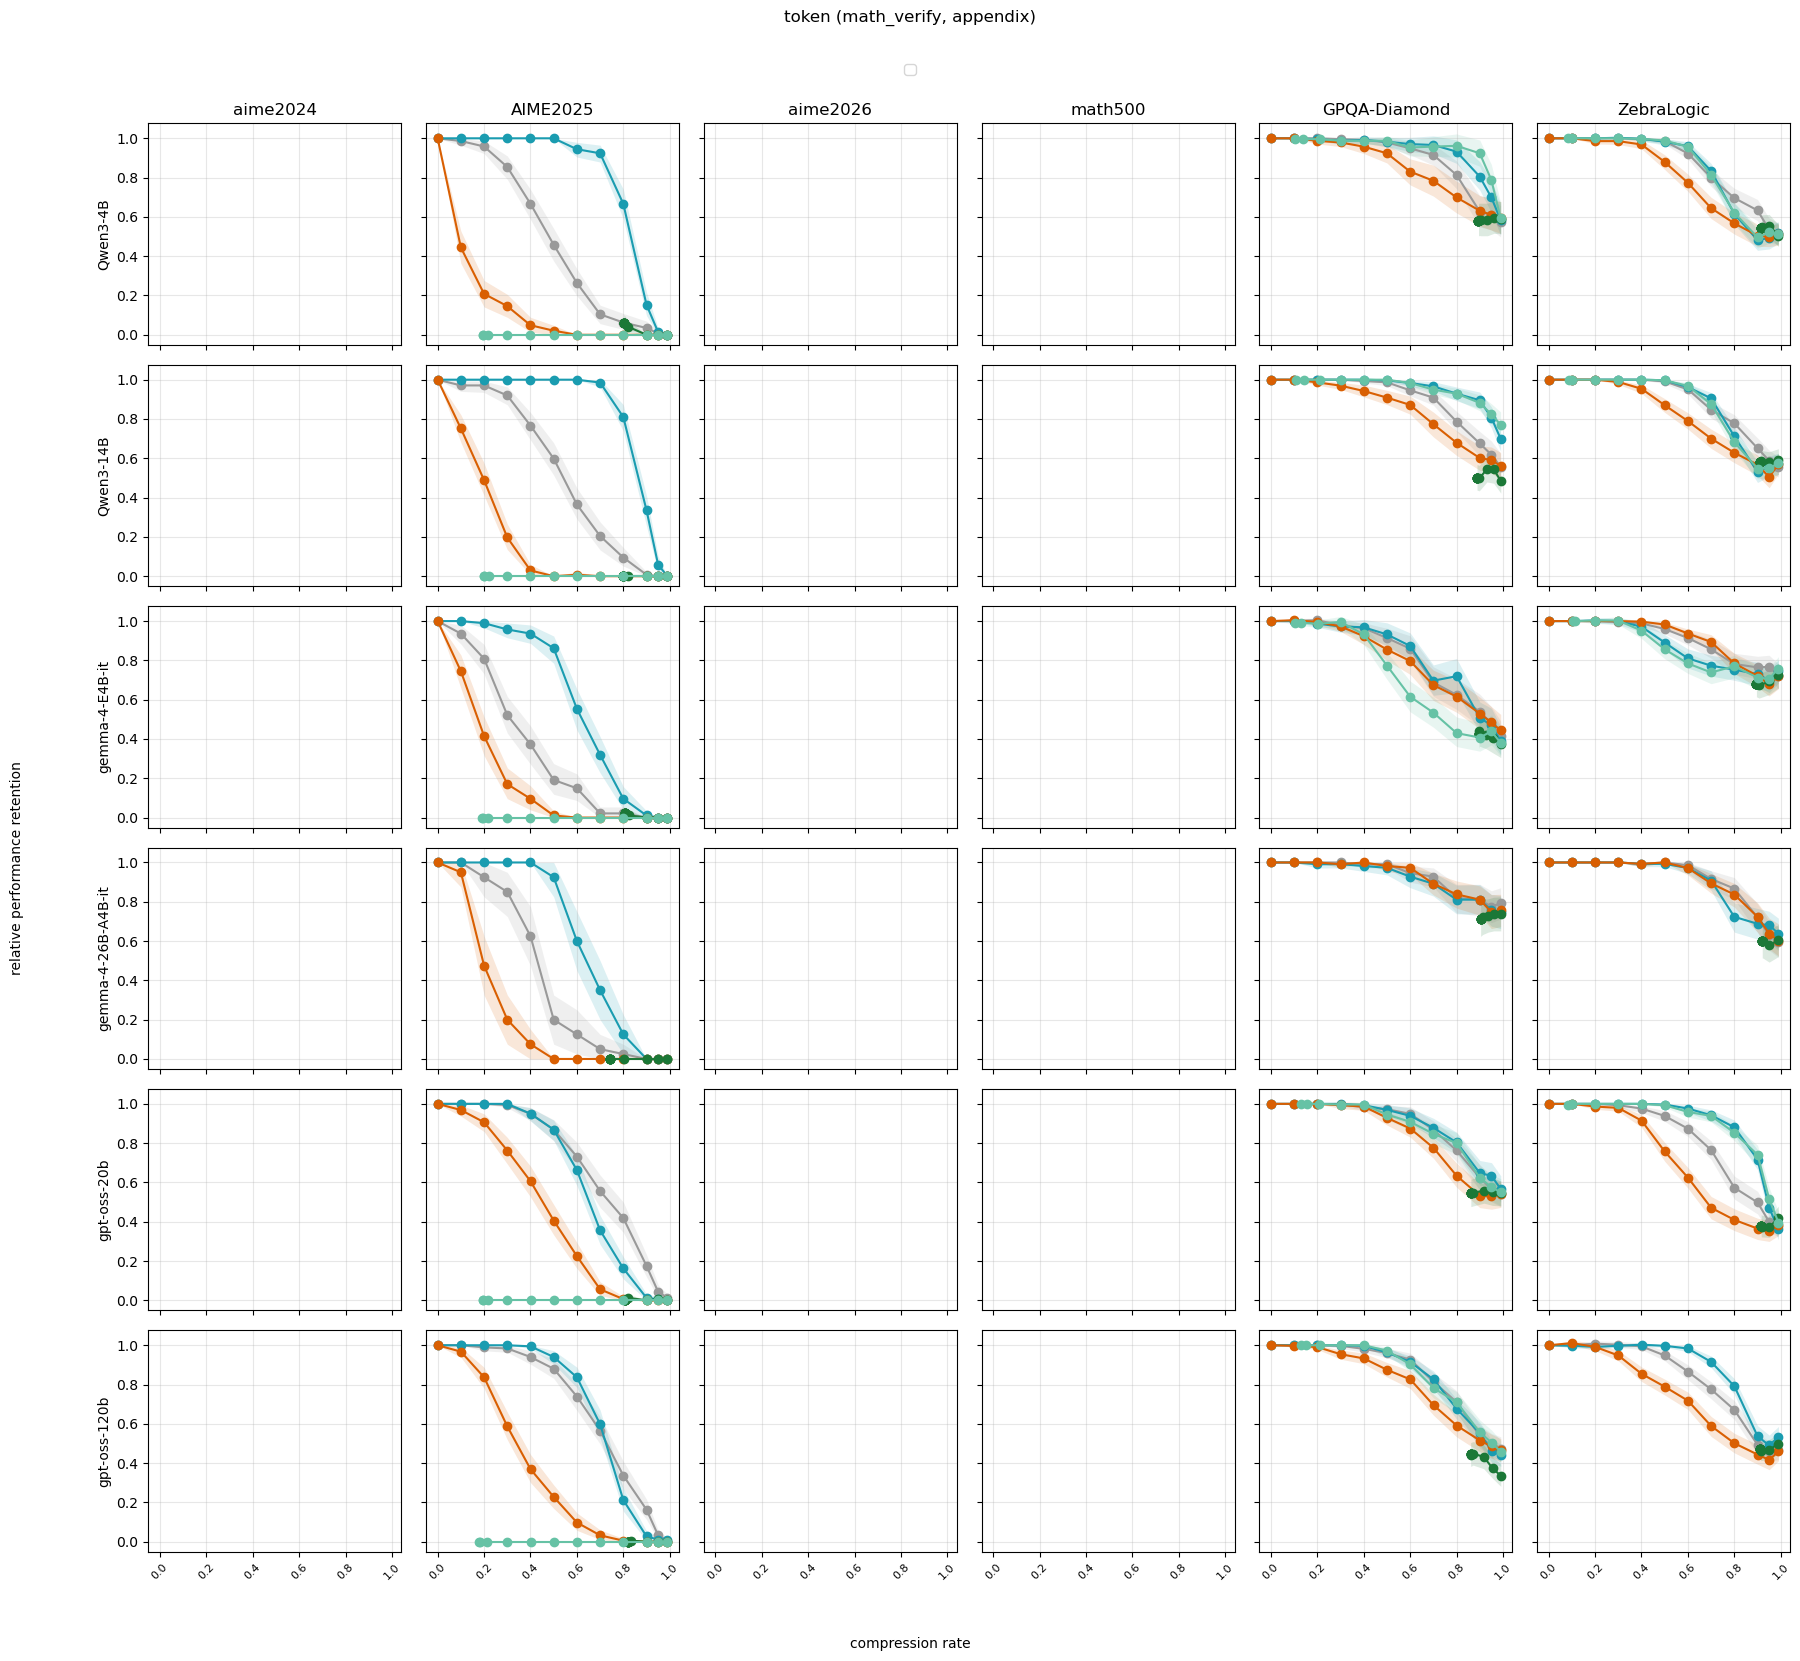

In [29]:
# Appendix figure: token-level, math_verify-based
plot_full_grid_semantic(
    models=MODELS,
    datasets=DATASETS,
    selectors=("random", "low_entropy", "high_entropy", "numbers", "low_entropy_no_numbers"),
    level="token",
    save="figures/appendix_full_grid_token_mathverify.pdf",
)

/tmp/ipykernel_5536/3939848128.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
Timeout during comparison
Timeout during comparison
Timeout during comparison
Timeout during comparison
Timeout during comparison
Timeout during comparison


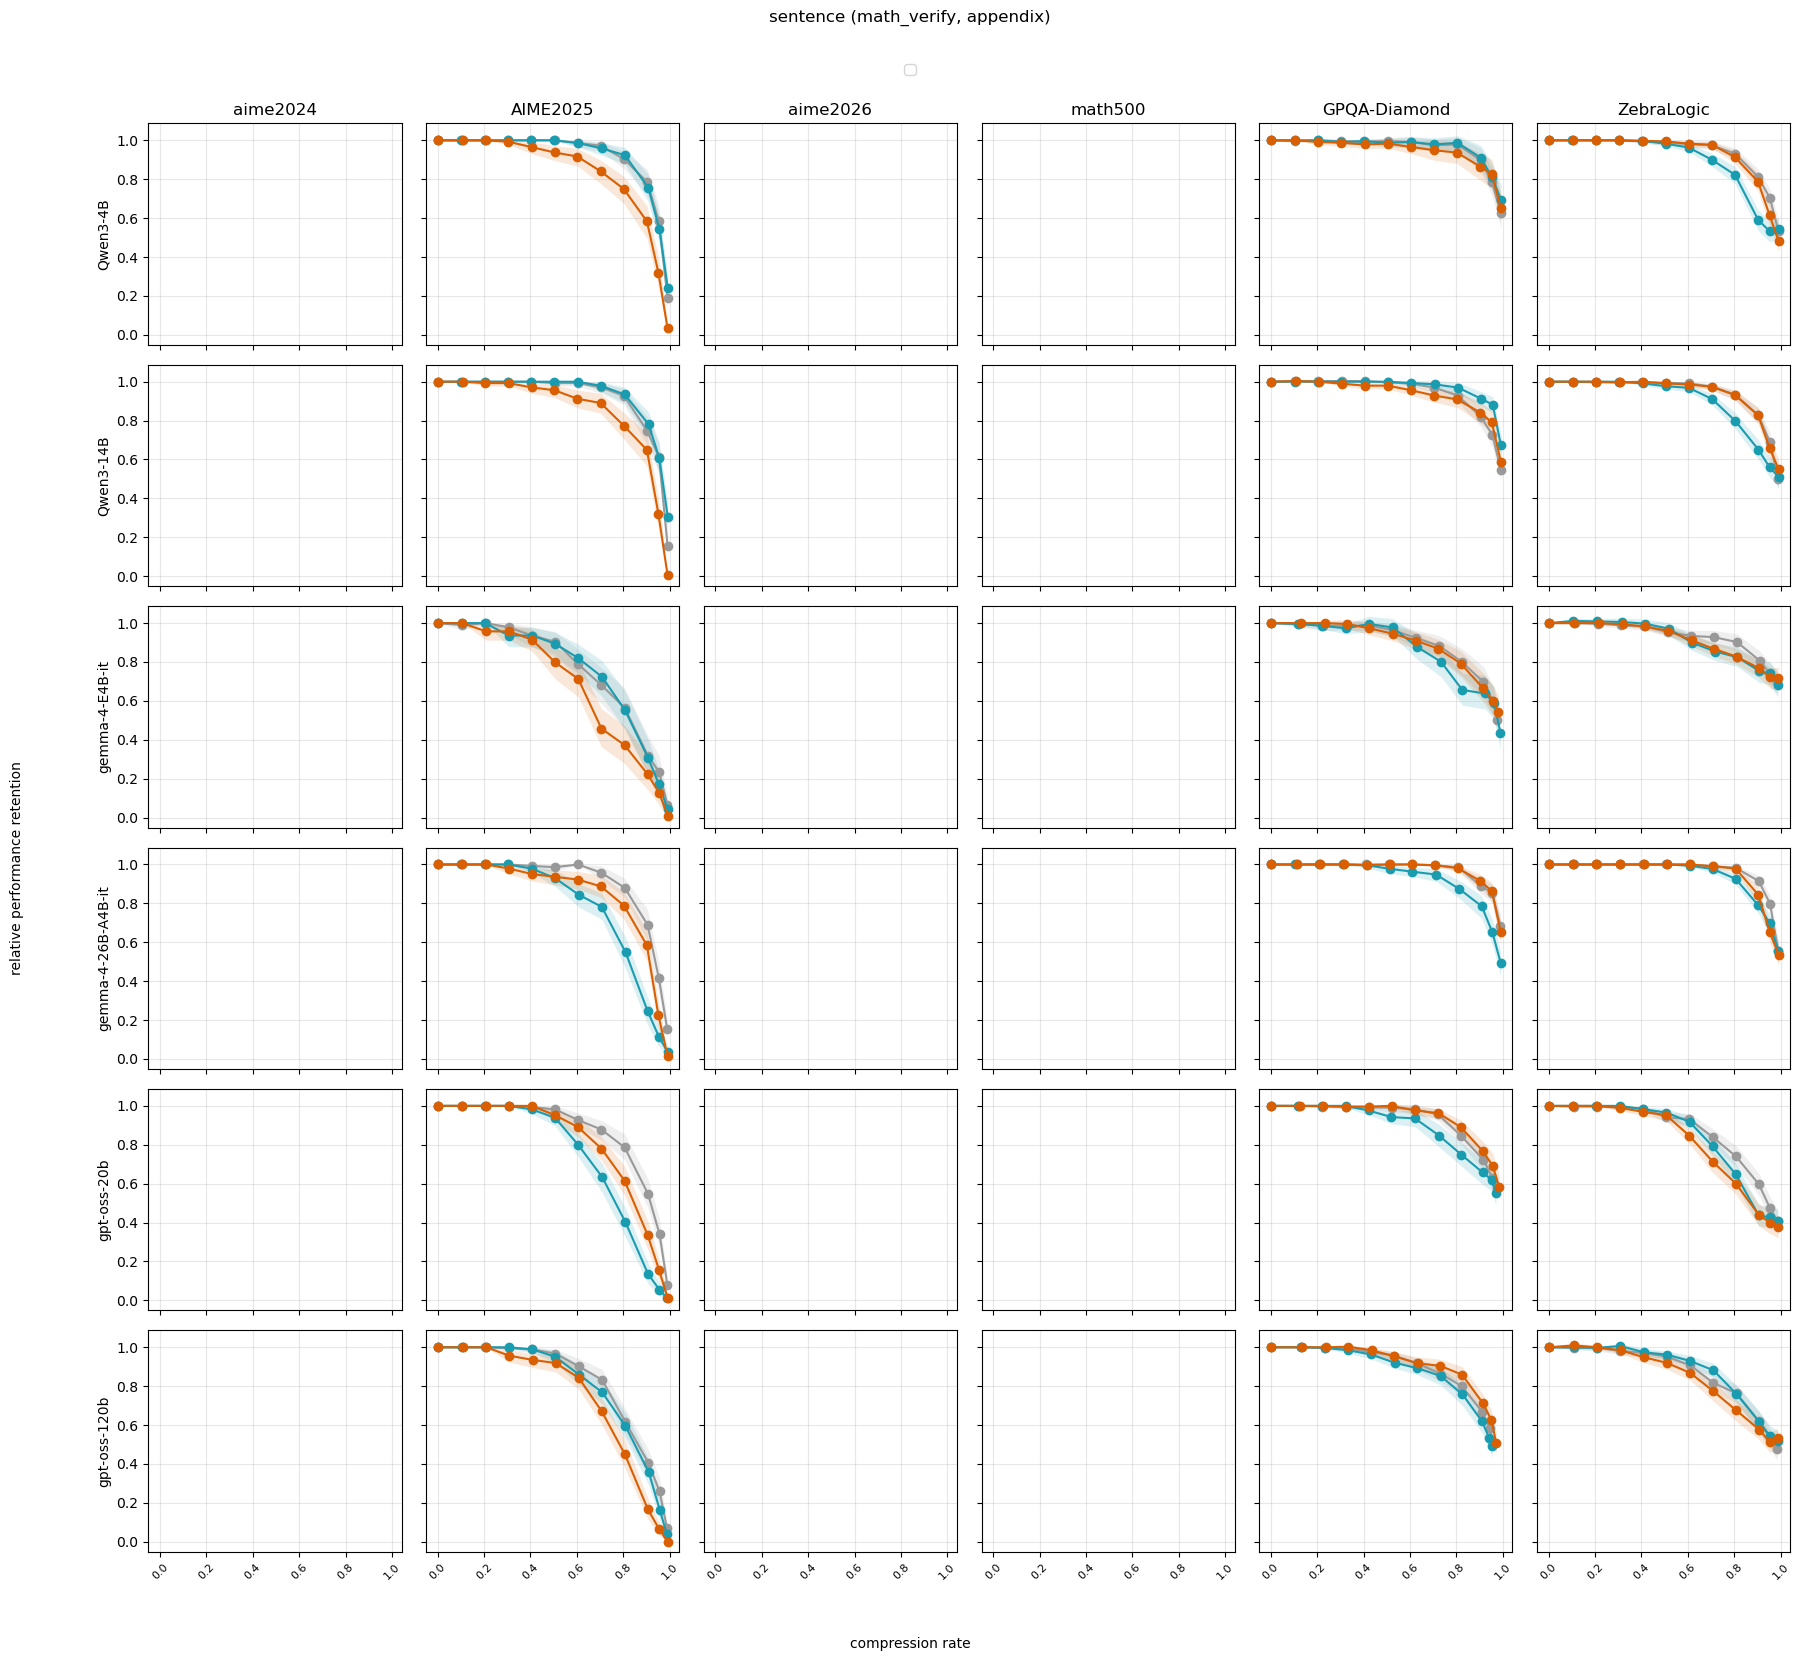

In [30]:
# Appendix figure: sentence-level, math_verify-based
plot_full_grid_semantic(
    models=MODELS,
    datasets=DATASETS,
    selectors=("random", "low_entropy", "high_entropy"),
    level="sentence",
    save="figures/appendix_full_grid_sentence_mathverify.pdf",
)

KeyboardInterrupt: 

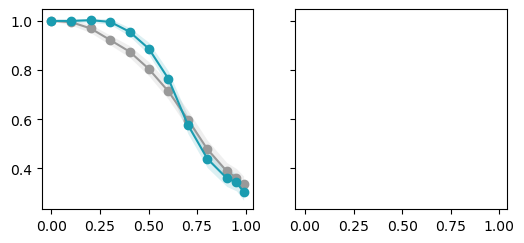

In [31]:
plot_full_grid_semantic(
    models=["gpt-oss-120b"],
    datasets=["math-500", "gpqa"],
    selectors=("random", "low_entropy", "high_entropy"),
    level="token",
)